<a href="https://colab.research.google.com/github/NU-MSE-LECTURES/465-WINTER2026/blob/main/Week_04/assignments/assignment_04_combined.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MAT_SCI 465: Advanced Electron Microscopy & Diffraction
## Week 03 & 04 Combined Assignment
**Classical, ML, and Deep Learning Approaches to Microscopy Analysis**

**Dataset:** DOPAD (Dataset Of nanoPArticle Detection) - TEM nanoparticle images for detection and classification  
**Dataset Source:** https://dopad.github.io/

## Objective
Compare classical computer vision, machine learning, and deep learning approaches on the same electron microscopy dataset. Progress from traditional image processing through supervised and unsupervised learning to modern deep learning, enabling direct quantitative comparison of all methods.

## Task 1 · Classical Image Analysis Pipeline
- [ ] Apply noise reduction (Gaussian, median, or FFT filtering) and compute signal-to-noise ratio before and after using $SNR = u / igma$.
- [ ] Enhance contrast via histogram equalization or CLAHE (clip limit 0.01-0.03).
- [ ] Segment features using Otsu thresholding followed by Watershed to separate touching particles.
- [ ] Quantify morphology with `regionprops` (area, diameter, eccentricity, solidity) and export measurements to `classical_results.csv`.
- [ ] Create a four-panel figure: raw image, filtered/enhanced result, segmented labels, particle size distribution.

In [1]:
# Task 1 setup: imports and data loading
from pathlib import Path
import numpy as np
import pandas as pd
from skimage import exposure, filters, measure, morphology, segmentation
from skimage.io import imread
from scipy import fft
import matplotlib.pyplot as plt
import os
import time

# DOPAD dataset: download from https://dopad.github.io/docs/download/
# After extraction, adjust IMAGE_DIR to your local path

# Use absolute path to ensure it works regardless of kernel working directory
IMAGE_DIR = Path('/Users/wkddk/matsci465/weeks3&4/raw_data')

print(f"Current working directory: {os.getcwd()}")
print(f"IMAGE_DIR: {IMAGE_DIR}")
print(f"IMAGE_DIR exists: {IMAGE_DIR.exists()}")

# Example: load a TEM image from DOPAD
# For PNG/standard formats:
if IMAGE_DIR.exists():
    sample_images = sorted(list(IMAGE_DIR.glob('*.png')) + list(IMAGE_DIR.glob('*.tif')))
    if sample_images:
        raw_image = imread(str(sample_images[0]))
        print(f"Loaded: {sample_images[0].name}, Shape: {raw_image.shape}")
        print(f"Total images available: {len(sample_images)}")
    else:
        print("No images found in DOPAD directory")
else:
    raw_image = None
    print("IMAGE_DIR path not found. Please download DOPAD dataset and update path.")

# Image is RGB-type, so this is a pre-processing step to make it into a normalized 1D array
raw_image = raw_image[:,:,0]

Current working directory: C:\Users\wkddk\matsci465\weeks3&4
IMAGE_DIR: \Users\wkddk\matsci465\weeks3&4\raw_data
IMAGE_DIR exists: True
Loaded: 11500X00.png, Shape: (416, 416, 4)
Total images available: 201


Signal to noise ratio before filtering: 4.852891679069054
Signal to noise ratio after filtering: 4.916273851132228
Runtime of this code block: 0.1510 s


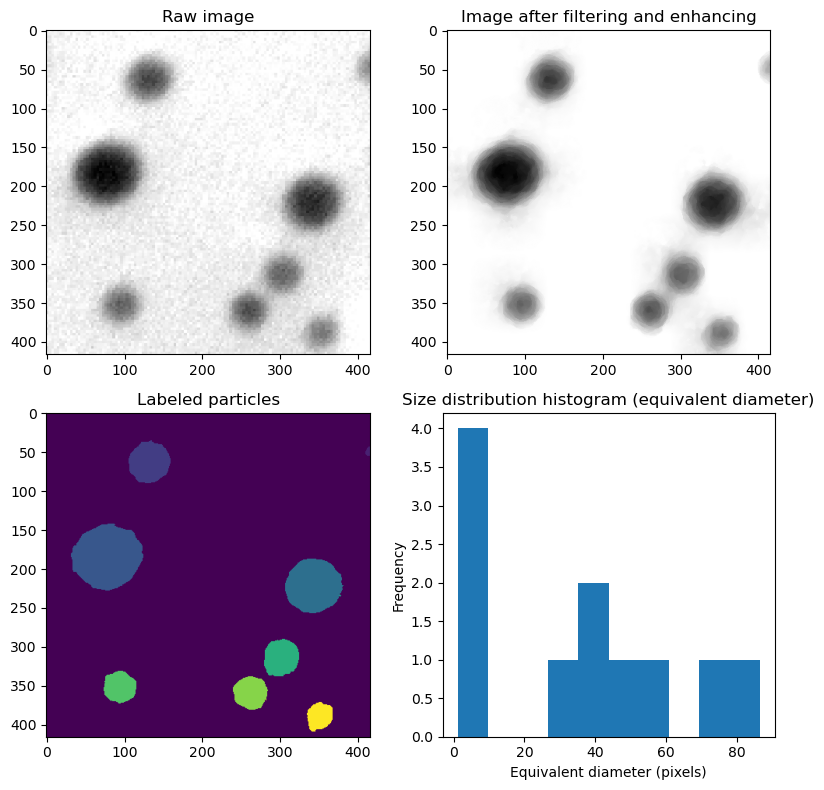

              area   perimeter  eccentricity   solidity  equivalent_diameter  \
count    11.000000   11.000000     11.000000  11.000000            11.000000   
mean   1608.545455  119.038685      0.412441   0.976039            35.598524   
std    1871.443046  100.713899      0.310424   0.016199            29.306820   
min       1.000000    0.000000      0.000000   0.956609             1.128379   
25%      30.500000   17.071068      0.291988   0.964940             5.483575   
50%    1353.000000  139.296465      0.331950   0.969652            41.505338   
75%    1987.500000  169.246212      0.492383   0.988636            50.209876   
max    5879.000000  297.078210      1.000000   1.000000            86.518063   

       intensity_min  intensity_max  intensity_mean  intensity_std  
count      11.000000      11.000000       11.000000      11.000000  
mean        0.409342       0.692527        0.550261       0.080463  
std         0.240084       0.000824        0.132184       0.068409  
min

In [260]:
# Task 1 processing: filtering, enhancement, segmentation, quantification
# HINTS for Task 1:
# 1. Filtering: Use filters.median() or filters.gaussian() from skimage.filters
#    Compare SNR before and after filtering to see improvement
# 2. Enhancement: Use exposure.equalize_adapthist() with clip_limit around 0.025
#    This will increase contrast without oversaturation
# 3. Segmentation: After Otsu thresholding, use scipy.ndimage.distance_transform_edt()
#    to find marker positions for Watershed
# 4. Regionprops: Pass intensity_image parameter to get min/max/mean intensity
#    Example: measure.regionprops(labels, intensity_image=enhanced_image)
# 5. Export: Use pd.DataFrame.to_csv() to save measurements

from skimage.segmentation import watershed
from scipy import ndimage as ndi
from skimage.feature import peak_local_max

def compute_snr(image: np.ndarray) -> float:
    signal = np.mean(image)
    noise = np.std(image)
    return float(signal / noise) if noise else np.inf

start_time = time.perf_counter()

# SNR before filtering
SNR_beforefilter = compute_snr(raw_image)

# Filtering hint: Try median filter for salt-and-pepper noise
filtered_image = ndi.median_filter(raw_image, footprint=morphology.disk(5))
SNR_afterfilter = compute_snr(filtered_image) # SNR after filtering

print(f'Signal to noise ratio before filtering: {SNR_beforefilter}')
print(f'Signal to noise ratio after filtering: {SNR_afterfilter}')

# Enhancement hint: CLAHE improves local contrast
enhanced_image = exposure.equalize_adapthist(filtered_image, clip_limit=0.005)

# Segmentation hint: Use Otsu's threshold followed by watershed
threshold = filters.threshold_otsu(enhanced_image)
binary = enhanced_image < threshold
binary = morphology.remove_small_objects(binary, max_size=20)
binary = morphology.remove_small_holes(binary, max_size=20)

# Then use distance transform + watershed to separate particles
distance = ndi.distance_transform_edt(binary)
coords = peak_local_max(distance, footprint=np.ones((3, 3)), labels=binary)
mask = np.zeros(distance.shape, dtype=bool)
mask[tuple(coords.T)] = True
markers, _ = ndi.label(mask)
labels = watershed(-distance, markers, mask=binary)

# Morphology hint: Extract area, perimeter, eccentricity, solidity, equivalent_diameter
# Store in a DataFrame, then save with measurements.to_csv()
properties = measure.regionprops(labels, intensity_image=enhanced_image)
proptable = measure.regionprops_table(labels, intensity_image=enhanced_image, properties=('area', 'perimeter', 'eccentricity', 'solidity', 'equivalent_diameter', 'intensity_min', 'intensity_max', 'intensity_mean', 'intensity_std'))
measurements = pd.DataFrame(proptable)
measurements.to_csv('classical_results.csv', index=False)

end_time = time.perf_counter()
classical_runtime = end_time - start_time

# Visualization hint: Create 2x2 subplot figure with:
# [Raw image] [Enhanced/Filtered]
# [Segmented labels] [Size distribution histogram]
# Use imshow() for images and hist() for distribution

print(f'Runtime of this code block: {classical_runtime:.4f} s')

fig, ax = plt.subplots(2, 2, figsize=(8,8))

ax[0, 0].imshow(raw_image, cmap='gray')
ax[0, 0].set_title('Raw image')

ax[0, 1].imshow(enhanced_image, cmap='gray')
ax[0, 1].set_title('Image after filtering and enhancing')

ax[1, 0].imshow(labels)
ax[1, 0].set_title('Labeled particles')

ax[1, 1].hist(proptable['equivalent_diameter'])
ax[1, 1].set_title('Size distribution histogram (equivalent diameter)')
ax[1, 1].set_xlabel('Equivalent diameter (pixels)')
ax[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()
print(measurements.describe())
fig.savefig('Classical4PanelCollage.png', dpi=300, bbox_inches='tight')

## Task 2 · Machine Learning Approaches
- [ ] Extract hand-crafted features: edges (Canny or Sobel), blobs (LoG), textures (LBP or GLCM) to build a feature matrix with at least 10 descriptors per region.
- [ ] Perform feature selection using Random Forest importance or correlation analysis; retain the top 5-7 discriminative features.
- [ ] Supervised: label data into two or more classes (≥50 samples), train SVM and Random Forest, then report precision, recall, F1-score, and confusion matrices.
- [ ] Unsupervised: run k-Means (k ∈ {3, 5, 7}) and visualize using PCA or t-SNE; compute silhouette scores.
- [ ] Compare ML outputs with classical segmentation regarding particle counts, accuracy, and runtime; export to `ml_results.csv`.

In [236]:
# Task 2: feature extraction and ML pipelines
from skimage.feature import canny, local_binary_pattern
from sklearn import metrics
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.manifold import TSNE
from sklearn.metrics import classification_report, confusion_matrix, silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# HINTS for Task 2:
# 1. Feature extraction: For each detected region, compute:
#    - Area, perimeter, equivalent diameter, eccentricity, solidity (from regionprops)
#    - Mean and std intensity (intensity-based features)
#    - Edge features: number of edges detected by Canny filter
#    - Texture: Local Binary Pattern variance
#    - Circularity = 4*pi*area / perimeter^2
#    - Total: 10+ features per region
#
# 2. Feature selection: Train a RandomForestClassifier and get feature_importances_
#    Keep top 5-7 features with highest importance scores
#    Hint: importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
#
# 3. Supervised ML:
#    - Split data into train/test (80/20)
#    - Scale features using StandardScaler()
#    - Train SVM with kernel='rbf' and Random Forest with n_estimators=100
#    - Compute F1-score: metrics.f1_score(y_true, y_pred)
#    - Create confusion matrix: metrics.confusion_matrix(y_true, y_pred)
#
# 4. Unsupervised ML:
#    - Run KMeans for k in [3, 5, 7]
#    - Compute silhouette_score(X_scaled, clusters) for each k
#    - Use PCA(n_components=2) to project to 2D for visualization
#    - Plot scatter with cluster labels as colors
#
# 5. Export: Save results to ml_results.csv with columns:
#    [Method, F1-Score, Precision, Recall, Silhouette_Score]

# TODO: assemble feature matrix and labels
# This function first finds all segmented regions from a series of images and then returns a list of properties of all regions.
def extract_features(imageseries):
    properties = {'area': [], 'perimeter': [], 'eccentricity': [], 'solidity': [], 'equivalent_diameter': [], 'intensity_mean': [], 'intensity_std': [], 'edges': [], 'texture': [], 'circularity': []}
    for image in imageseries:
        image = image[:,:,0]
        filtered_image = filters.median(image, footprint=morphology.disk(5))
        enhanced_image = exposure.equalize_adapthist(filtered_image, clip_limit=0.005)
        threshold = filters.threshold_otsu(enhanced_image)
        binary = enhanced_image < threshold
        binary = morphology.remove_small_objects(binary, max_size=20)
        binary = morphology.remove_small_holes(binary, max_size=20)
        distance = ndi.distance_transform_edt(binary)
        coords = peak_local_max(distance, footprint=np.ones((3, 3)), labels=binary)
        mask = np.zeros(distance.shape, dtype=bool)
        mask[tuple(coords.T)] = True
        markers, _ = ndi.label(mask)
        labels = watershed(-distance, markers, mask=binary)

        regions = measure.regionprops(labels, intensity_image=enhanced_image)
        region_proptable = measure.regionprops_table(labels, intensity_image=enhanced_image, properties=('area', 'perimeter', 'eccentricity', 'solidity', 'equivalent_diameter', 'intensity_mean', 'intensity_std'))
        for i, region in enumerate(regions):
            zoomed_in_img = image[region.bbox[0]:region.bbox[2], region.bbox[1]:region.bbox[3]]
            mask = region.image
        
            properties['area'].append(region_proptable['area'][i])
            properties['perimeter'].append(region_proptable['perimeter'][i])
            properties['eccentricity'].append(region_proptable['eccentricity'][i])
            properties['solidity'].append(region_proptable['solidity'][i])
            properties['equivalent_diameter'].append(region_proptable['equivalent_diameter'][i])
            properties['intensity_mean'].append(region_proptable['intensity_mean'][i])
            properties['intensity_std'].append(region_proptable['intensity_std'][i])
            properties['edges'].append(np.sum(canny(zoomed_in_img)) / region_proptable['area'][i])
            properties['texture'].append(np.var(local_binary_pattern(zoomed_in_img, P=8, R=1, method='uniform')))
            properties['circularity'].append(4*np.pi*region_proptable['area'][i]/region_proptable['perimeter'][i]**2 if region_proptable['perimeter'][i] > 0 else 0)

    return properties

imageseries = []
for i in range(50):
    imageseries.append(imread(str(sample_images[i])))

X = extract_features(imageseries)

features = pd.DataFrame(X)
labels = pd.Series(X)
features

,area,perimeter,eccentricity,solidity,equivalent_diameter,intensity_mean,intensity_std,edges,texture,circularity
0,57.0,29.899495,0.886451,0.966102,8.519076,0.681627,0.014225,0.210526,3.350427,0.801230
1,2231.0,179.438600,0.314983,0.963715,53.297255,0.452885,0.132902,0.295383,3.226056,0.870718
2,5879.0,297.078210,0.435678,0.969652,86.518063,0.309373,0.203072,0.271305,3.110022,0.837089
3,3999.0,237.622366,0.326430,0.977273,71.356043,0.377985,0.164761,0.282571,3.282945,0.889993
4,1.0,0.000000,0.000000,1.000000,1.128379,0.690917,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...
1157,3816.0,233.379726,0.216546,0.973966,69.704247,0.311622,0.182420,0.255241,3.197524,0.880424
1158,1005.0,118.083261,0.321941,0.971954,35.771577,0.521957,0.072420,0.235821,3.523506,0.905731
1159,1.0,0.000000,0.000000,1.000000,1.128379,0.652038,0.000000,0.000000,0.000000,0.000000
1160,690.0,98.325902,0.323816,0.966387,29.640096,0.560948,0.050833,0.191304,3.290433,0.896857


I will classify the particles based on how circular vs. elliptical they are (i.e. "good" vs. "bad" nanoparticles).

In [237]:
# TODO: perform feature selection and train supervised models
# Feature selection hint:
# rf_importance = RandomForestClassifier(n_estimators=100, random_state=42)
# rf_importance.fit(X, y)
# top_features = np.argsort(rf_importance.feature_importances_)[-7:]
# svm_model = SVC(kernel='rbf')

property_names = ['area', 'perimeter', 'eccentricity', 'solidity', 'equivalent_diameter', 'intensity_mean', 'intensity_std', 'edges', 'texture', 'circularity']
classifier_labels = (features['eccentricity'] <= 0.5) # if true or 1, this is circular. if false or 0, this is elliptical.

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

rf_importance = RandomForestClassifier(n_estimators=100, random_state=42)
rf_importance.fit(X_scaled, classifier_labels)
top_features = np.flip(np.argsort(rf_importance.feature_importances_)[-7:])
top_features = [property_names[val] for i, val in enumerate(top_features)]
top_importances = np.flip(np.sort(rf_importance.feature_importances_)[-7:])

feature_importance = pd.DataFrame({
    'feature': top_features,
    'importance': top_importances
})

feature_importance

,feature,importance
0,eccentricity,0.556513
1,circularity,0.164502
2,area,0.082668
3,equivalent_diameter,0.076067
4,perimeter,0.038365
5,intensity_std,0.022475
6,solidity,0.021727


As we would expect, the eccentricity and circularity of the nanoparticles are the most important features in determining how circular vs. elliptical a nanoparticle is.

,RandomForest,SVM
model,"(DecisionTreeClassifier(max_features='sqrt', r...",SVC()
precision,1.0,1.0
recall,0.943396,1.0
f1_score,0.970874,1.0
confusion_matrix,"[[180, 0], [3, 50]]","[[180, 0], [0, 53]]"
runtime,0.092939,0.004934


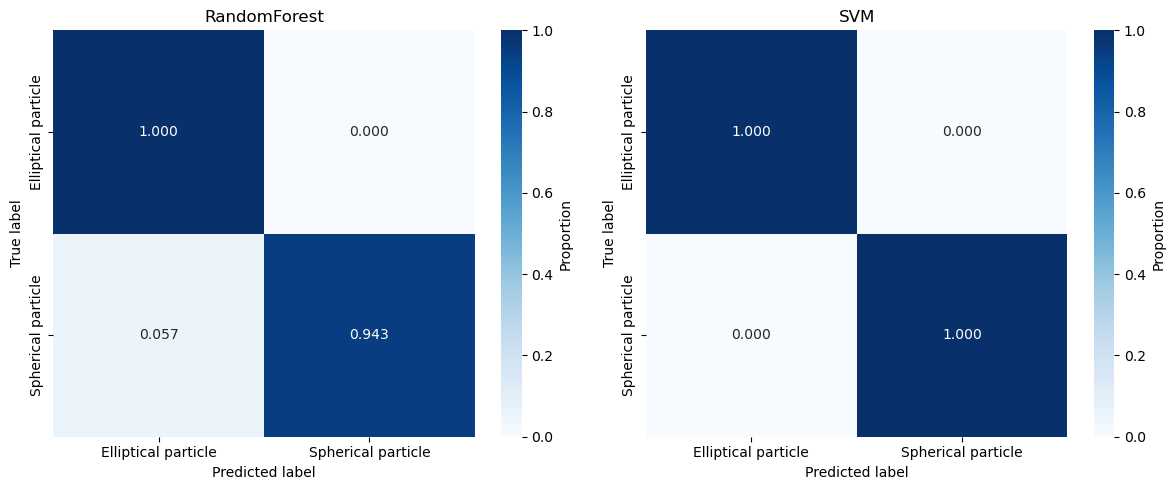

In [261]:
# TODO: evaluate models, generate confusion matrices, export results
import seaborn

X_tot = np.array([X['eccentricity'], X['circularity'], X['edges'], X['area'], X['equivalent_diameter'], X['perimeter'], X['intensity_std']])
X_tot = np.transpose(X_tot)
y = classifier_labels
X_train, X_test, y_train, y_test = train_test_split(X_tot, y, test_size=0.2, random_state=42, stratify=classifier_labels)

models = {'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42), 'SVM': SVC(kernel='rbf')}
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

results = {}

for name, model in models.items():
    start_time = time.perf_counter()
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    f1 = metrics.f1_score(y_test, y_pred)
    confusion_matrix = metrics.confusion_matrix(y_test, y_pred)
    end_time = time.perf_counter()
    
    results[name] = {
        'model': model,
        'precision': metrics.precision_score(y_test, y_pred),
        'recall': metrics.recall_score(y_test, y_pred),
        'f1_score': metrics.f1_score(y_test, y_pred),
        'confusion_matrix': metrics.confusion_matrix(y_test, y_pred),
        'runtime': end_time - start_time
    }

ml_results = pd.DataFrame(results)
ml_results.to_csv('ml_results.csv', index=False)
display(ml_results)

# Confusion matrix visualization hint:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
for i, (name, result) in enumerate(results.items()):
    cm = result['confusion_matrix']
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    seaborn.heatmap(cm_norm, annot=True, fmt='.3f', cmap='Blues',
                   xticklabels=['Elliptical particle', 'Spherical particle'],
                   yticklabels=['Elliptical particle', 'Spherical particle'],
                   ax=axes[i], cbar_kws={'label': 'Proportion'})
    axes[i].set_title(name)
    axes[i].set_xlabel('Predicted label')
    axes[i].set_ylabel('True label')

plt.tight_layout()
fig.savefig('ConfusionMatrices.png', dpi=300, bbox_inches='tight')

C:\Users\wkddk\miniconda3\envs\ms465-2026\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\wkddk\miniconda3\envs\ms465-2026\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\wkddk\miniconda3\envs\ms465-2026\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


Silhouette score for k = 3: 0.685
Silhouette score for k = 5: 0.651
Silhouette score for k = 7: 0.629

Runtime for k-means (k=3): 0.0098 s
Runtime for k-means (k=5): 0.0134 s
Runtime for k-means (k=7): 0.0103 s


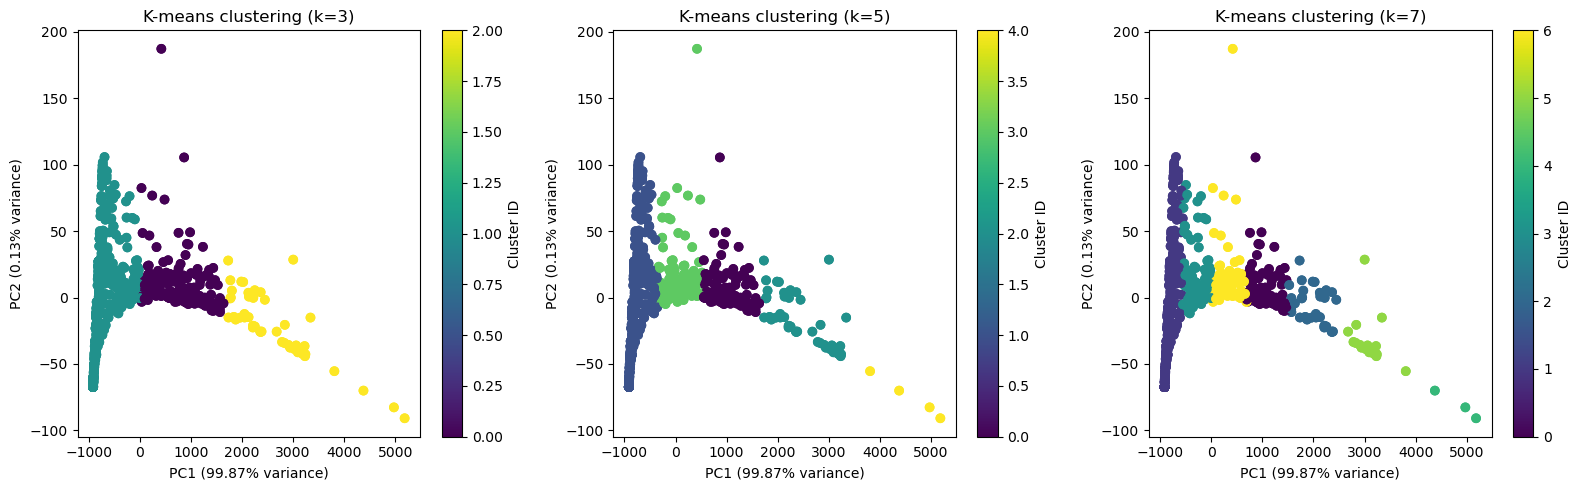

In [262]:
# TODO: run unsupervised clustering and visualize embeddings
# K-Means hint: clusters = KMeans(n_clusters=k, random_state=42).fit_predict(X_scaled)
# PCA visualization: X_pca = PCA(n_components=2).fit_transform(X_scaled)
#                   plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters)

ks = [3, 5, 7]
silhouette_scores = []
labels = []
features_scaled = scaler.fit_transform(classifier_labels.values.reshape(-1,1))
kmeans_runtimes = []

for k in ks:
    start_time = time.perf_counter()
    clusters = KMeans(n_clusters=k, random_state=42).fit_predict(X_tot)
    end_time = time.perf_counter()
    labels.append(clusters)
    kmeans_runtimes.append(end_time - start_time)
    silhouette_scores.append(silhouette_score(X_tot, clusters))
    print(f'Silhouette score for k = {k}: {silhouette_score(X_tot, clusters):.3f}')

pca = PCA(n_components=2)
features_pca = pca.fit_transform(X_tot)
print(f'\nRuntime for k-means (k=3): {kmeans_runtimes[0]:.4f} s')
print(f'Runtime for k-means (k=5): {kmeans_runtimes[1]:.4f} s')
print(f'Runtime for k-means (k=7): {kmeans_runtimes[2]:.4f} s')

fig, axs = plt.subplots(1, 3, figsize=(16,5))

scatter1 = axs[0].scatter(features_pca[:,0], features_pca[:,1], c=labels[0])
axs[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
axs[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
axs[0].set_title('K-means clustering (k=3)')
plt.colorbar(scatter1, ax=axs[0], label='Cluster ID')

scatter2 = axs[1].scatter(features_pca[:,0], features_pca[:,1], c=labels[1])
axs[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
axs[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
axs[1].set_title('K-means clustering (k=5)')
plt.colorbar(scatter2, ax=axs[1], label='Cluster ID')

scatter3 = axs[2].scatter(features_pca[:,0], features_pca[:,1], c=labels[2])
axs[2].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
axs[2].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
axs[2].set_title('K-means clustering (k=7)')
plt.colorbar(scatter3, ax=axs[2], label='Cluster ID')

plt.tight_layout()
fig.savefig('kmeanscollage.png', dpi=300, bbox_inches='tight')

## Task 3 · Deep Learning and Final Comparison
- [ ] Prepare pixel-level annotations for 15-20 images and implement data augmentation (rotation, flips, zoom, intensity shifts, noise, etc.; 5+ variants).
- [ ] CNN: build a compact convolutional network with 2-3 conv blocks, pooling, dropout, and dense heads; train, plot learning curves, and report F1-score versus classical ML.
- [ ] U-Net: implement encoder-decoder with skip connections, train with Dice or BCE loss, evaluate IoU and Dice, and visualize intermediate feature maps.
- [ ] Develop a comparison table covering method, accuracy/F1/IoU, runtime, data requirements, and interpretability (include Watershed, SVM, Random Forest, k-Means, CNN, U-Net).
- [ ] Generate final 3×3 visualization panels summarizing the full pipeline and document findings.
- [ ] Author README.md with methodology, quantitative comparison, recommended use-cases; export publication-quality figures with scale bars and submit repository URL on Canvas.

I first need to generate some new datasets for the CNN.

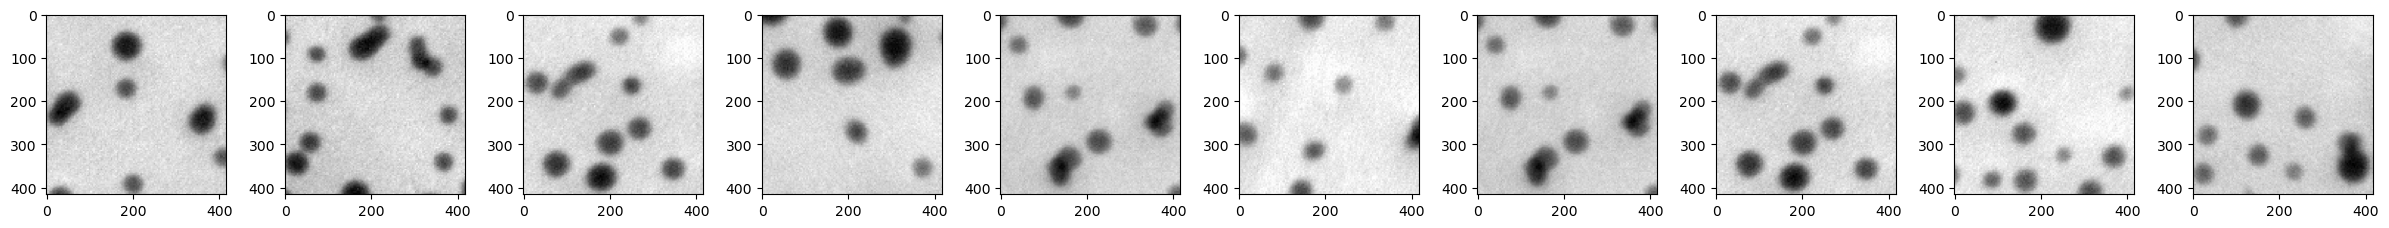

In [221]:
def find_cropped_segments(raw_image):
    raw_image = raw_image[:,:,0]
    filtered_image_test = filters.median(raw_image, footprint=morphology.disk(5))
    enhanced_image_test = exposure.equalize_adapthist(filtered_image_test, clip_limit=0.004)
    threshold_test = filters.threshold_otsu(enhanced_image_test)
    binary_test = enhanced_image_test < threshold_test
    binary_test = morphology.remove_small_objects(binary_test, max_size=20)
    binary_test = morphology.remove_small_holes(binary_test, max_size=20)
    distance_test = ndi.distance_transform_edt(binary_test)
    coords_test = peak_local_max(distance_test, footprint=np.ones((3, 3)), labels=binary_test)
    mask_test = np.zeros(distance_test.shape, dtype=bool)
    mask_test[tuple(coords_test.T)] = True
    markers_test, _test = ndi.label(mask_test)
    labels_test = watershed(-distance_test, markers_test, mask=binary_test)
    regions_test = measure.regionprops(labels_test, intensity_image=enhanced_image_test)
    cropped_imgs = []
    final_img_size = 128 # 128 x 128 pixel image
    for region in regions_test:
        
        # region.bbox is (min_row, min_col, max_row, max_col)
        r0, c0, r1, c1 = region.bbox
    
        # Use region centroid to center the 128x128 window
        r_center, c_center = region.centroid  # (row, col)
    
        half = final_img_size // 2
    
        # Place a 128 window centered at the region (integer rounding)
        r_start = int(round(r_center)) - half
        c_start = int(round(c_center)) - half
    
        # FIX 2: clamp so the window stays inside the image (snap to edge/corner if needed)
        r_start = max(0, min(r_start, raw_image.shape[0] - final_img_size))
        c_start = max(0, min(c_start, raw_image.shape[1] - final_img_size))
    
        r_end = r_start + final_img_size
        c_end = c_start + final_img_size
    
        # Final safety: enforce exact shape 128x128
        crop = raw_image[r_start:r_end, c_start:c_end]
        if crop.shape != (final_img_size, final_img_size):
            # In rare rounding cases or very small images, snap again
            r_end = min(H, r_start + final_img_size)
            c_end = min(W, c_start + final_img_size)
            r_start = max(0, r_end - final_img_size)
            c_start = max(0, c_end - final_img_size)
            crop = raw_image[r_start:r_end, c_start:c_end]
    
        cropped_imgs.append(crop)

    return cropped_imgs

random_indices = np.random.randint(100, size=10)
raw_images = []
for idx in random_indices:
    raw_images.append(imread(sample_images[idx]))

fig, axs = plt.subplots(1, 10, figsize=(24,5))
for i in range(10):
    axs[i].imshow(raw_images[i])
plt.tight_layout()

In [319]:
from PIL import Image

all_cropped_imgs = []
for i in range(len(raw_images)):
    all_cropped_imgs.append(find_cropped_segments(raw_images[i]))
out_dir = Path('./all_cropped_imgs_for_CNN')

if not os.path.isdir(out_dir):
    os.makedirs(dir_path)
    print("Directory created.")
else:
    # Skip
    print("Directory already exists. Skipping...")

for i in range(len(all_cropped_imgs)):
    for j, arr in enumerate(all_cropped_imgs[i], start=1):
        filename = f'img{i}--{j}.png'
        Image.fromarray(arr, mode='L').save(out_dir / filename)

Directory already exists. Skipping...


I have to handpick some representative datasets from cropped segments of a random assortment of these images to train my CNN.

In [292]:
good_imgs_idx = [[0,3], [0,5], [0,10], [0,14], [1,3], [1,5], [1,11], [1,16], [1,18],
            [1,31], [1,37], [2,3], [2,6], [2,14], [3,2], [3,9], [3,11], [4,6],
            [4,10], [4,16], [4,19], [5,4], [5,5], [6,13], [6,17], [6,19], [7,15],
            [7,24], [7,28], [8,1], [8,12], [9,2], [9,4], [9,9], [9,12]] 
associated_labels = ['circular', 'elliptical', 'circular', 'circular', 'elliptical', 'circular', 'elliptical', 'elliptical', 'circular',
                    'circular', 'circular', 'circular', 'elliptical', 'elliptical', 'circular', 'elliptical', 'elliptical', 'circular',
                    'circular', 'elliptical', 'circular', 'circular', 'circular', 'circular', 'elliptical', 'circular', 'elliptical',
                    'circular', 'circular', 'circular', 'circular', 'circular', 'circular', 'elliptical', 'circular']
good_imgs = []
for i in range(len(associated_labels)):
    good_imgs.append(all_cropped_imgs[good_imgs_idx[i][0]][good_imgs_idx[i][1]])

In [299]:
from PIL import Image
from collections import defaultdict

# ---- CONFIG ----
OUT_DIR = Path('./CNN_dataset')
IMAGE_FORMAT = "png"

assert len(good_imgs) == len(associated_labels)

# Make class folders
classes = sorted(set(associated_labels))
for c in classes:
    (OUT_DIR / c).mkdir(parents=True, exist_ok=True)

# Save images into class folders
counters = defaultdict(int)
for i, (arr, label) in enumerate(zip(good_imgs, associated_labels), start=1):
    if arr.ndim != 2:
        raise ValueError(f"Expected 2D grayscale array; got shape {arr.shape} at index {i-1}")
    if arr.dtype != 'uint8':
        raise ValueError(f"Expected dtype uint8; got {arr.dtype} at index {i-1}")

    counters[label] += 1
    filename = f"img{counters[label]:06d}.{IMAGE_FORMAT}"
    Image.fromarray(arr, mode="L").save(OUT_DIR / label / filename)

print(f"✓ Wrote images by class to {OUT_DIR.resolve()}")

✓ Wrote images by class to C:\Users\wkddk\matsci465\weeks3&4\CNN_dataset


RUN FROM HERE

In [12]:
import os
from pathlib import Path
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, array_to_img
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [1]:
# Task 3: deep learning workflow templates

# HINTS for Task 3:
# 1. Data preparation:
#    - Use ImageDataGenerator with augmentation parameters:
#      rotation_range=30, width_shift_range=0.2, height_shift_range=0.2,
#      zoom_range=0.2, fill_mode='reflect'
#    - Normalize pixel values to [0, 1]
#    - Use flow_from_directory() or flow() from keras preprocessing
#
# 2. CNN Architecture (simple but effective):
#    - Conv2D(32, 3x3) + BatchNorm + ReLU + MaxPool(2x2)
#    - Conv2D(64, 3x3) + BatchNorm + ReLU + MaxPool(2x2)
#    - Flatten + Dense(128) + Dropout(0.5) + Dense(num_classes)
#    - Compile with optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy']
#    - Train with model.fit(train_dataset, validation_data=val_dataset, epochs=20)
#
# 3. U-Net Architecture (for segmentation):
#    - Encoder: Conv -> MaxPool (downsampling)
#    - Decoder: UpSampling -> Conv (upsampling)
#    - Skip connections: concatenate encoder features with decoder features
#    - Output: single channel with sigmoid activation (binary segmentation)
#    - Loss: keras.losses.BinaryCrossentropy() or Dice loss
#
# 4. Evaluation metrics:
#    - CNN: F1-score = 2 * (precision * recall) / (precision + recall)
#    - U-Net: IoU = intersection / union, Dice = 2 * intersection / (A + B)
#    - Hint: Use sklearn.metrics.f1_score, precision_score, recall_score
#
# 5. Visualization:
#    - Plot training curves: plt.plot(history.history['loss'], label='train')
#    - Show ground truth vs predictions side by side
#    - Display intermediate feature maps from encoder layers

# TODO: build data loaders with augmentation pipelines

# Data augmentation hint:
# from tensorflow.keras.preprocessing.image import ImageDataGenerator
# datagen = ImageDataGenerator(
#     rotation_range=30,
#     width_shift_range=0.2,
#     height_shift_range=0.2,
#     zoom_range=0.2,
#     fill_mode='reflect'
# )
# train_dataset = datagen.flow_from_directory('train_path', target_size=(416, 416))

# ---------------- CONFIG ----------------
BASE_DIR = Path('/Users/wkddk/matsci465/weeks3&4/CNN_dataset')
CLASSES = ['circular', 'elliptical']
N_AUG = 10                 # number of augmented images per original
TARGET_SIZE = (128,128)   # or None to keep original size
COLOR_MODE = 'rgb'        # or 'grayscale'
SEED = 42
# ----------------------------------------

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    fill_mode='reflect'
)

def get_next_index(class_dir):
    """Find next index + zero‑pad width from existing img0000xx.png files."""
    idxs = []
    for fname in os.listdir(class_dir):
        if fname.startswith("img") and fname.endswith(".png"):
            try:
                idxs.append(int(fname[3:-4]))
            except:
                pass
    if len(idxs) == 0:
        return 1, 6
    max_idx = max(idxs)
    width = len(str(max_idx))
    return max_idx + 1, width

for cls in CLASSES:
    class_dir = BASE_DIR / cls
    originals = [f for f in class_dir.iterdir() if f.suffix.lower() in ['.png','.jpg','.jpeg']]
    next_idx, width = get_next_index(class_dir)

    print(f"{cls}: {len(originals)} originals → saving {N_AUG * len(originals)} augmented images...")

    for img_path in originals:
        img = load_img(str(img_path), target_size=TARGET_SIZE, color_mode=COLOR_MODE)
        x = img_to_array(img)[None, ...]   # shape (1, H, W, C)

        # generator that yields augmented versions
        aug_iter = datagen.flow(x, batch_size=1, seed=SEED)

        for i in range(N_AUG):
            batch = next(aug_iter)[0]
            aug = array_to_img(batch)
            fname = f"img{next_idx:0{width}d}.png"
            aug.save(class_dir / fname)
            next_idx += 1

print("\nDone! Augmented images saved.")

circular: 23 originals → saving 230 augmented images...
elliptical: 12 originals → saving 120 augmented images...

Done! Augmented images saved.


In [31]:
# Running one more time to generate an even larger dataset to train with
# ---------------- CONFIG ----------------
BASE_DIR = Path('/Users/wkddk/matsci465/weeks3&4/CNN_dataset')
CLASSES = ['circular', 'elliptical']
N_AUG = 3                 # number of augmented images per original
TARGET_SIZE = (128,128)   # or None to keep original size
COLOR_MODE = 'rgb'        # or 'grayscale'
SEED = 42

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    fill_mode='reflect'
)

def get_next_index(class_dir):
    """Find next index + zero‑pad width from existing img0000xx.png files."""
    idxs = []
    for fname in os.listdir(class_dir):
        if fname.startswith("img") and fname.endswith(".png"):
            try:
                idxs.append(int(fname[3:-4]))
            except:
                pass
    if len(idxs) == 0:
        return 1, 6
    max_idx = max(idxs)
    width = len(str(max_idx))
    return max_idx + 1, width

for cls in CLASSES:
    class_dir = BASE_DIR / cls
    originals = [f for f in class_dir.iterdir() if f.suffix.lower() in ['.png','.jpg','.jpeg']]
    next_idx, width = get_next_index(class_dir)

    print(f"{cls}: {len(originals)} originals → saving {N_AUG * len(originals)} augmented images...")

    for img_path in originals:
        img = load_img(str(img_path), target_size=TARGET_SIZE, color_mode=COLOR_MODE)
        x = img_to_array(img)[None, ...]   # shape (1, H, W, C)

        # generator that yields augmented versions
        aug_iter = datagen.flow(x, batch_size=1, seed=SEED)

        for i in range(N_AUG):
            batch = next(aug_iter)[0]
            aug = array_to_img(batch)
            fname = f"img{next_idx:0{width}d}.png"
            aug.save(class_dir / fname)
            next_idx += 1

print("\nDone! Augmented images saved.")

circular: 2783 originals → saving 8349 augmented images...
elliptical: 1452 originals → saving 4356 augmented images...

Done! Augmented images saved.


In [36]:
train_dataset = datagen.flow_from_directory(
    '/Users/wkddk/matsci465/weeks3&4/CNN_dataset',
    target_size=(128,128),
    batch_size=256,
    class_mode='categorical',
    color_mode='grayscale',
    subset='training',
    shuffle=True,
    seed=SEED
)

val_dataset = datagen.flow_from_directory(
    '/Users/wkddk/matsci465/weeks3&4/CNN_dataset',
    target_size=(128,128),
    batch_size=256,
    class_mode='categorical',
    color_mode='grayscale',
    subset='validation',
    shuffle=True,
    seed=SEED
)

Found 13553 images belonging to 2 classes.
Found 3387 images belonging to 2 classes.


In [40]:
# TODO: define CNN model
#    - Conv2D(32, 3x3) + BatchNorm + ReLU + MaxPool(2x2)
#    - Conv2D(64, 3x3) + BatchNorm + ReLU + MaxPool(2x2)
#    - Flatten + Dense(128) + Dropout(0.5) + Dense(num_classes)
#    - Compile with optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy']
#    - Train with model.fit(train_dataset, validation_data=val_dataset, epochs=20)

# CNN model hint:
# model = keras.Sequential([
#     layers.Conv2D(32, 3, activation='relu', padding='same', input_shape=(416, 416, 1)),
#     layers.BatchNormalization(),
#     layers.MaxPooling2D(2),
#     layers.Conv2D(64, 3, activation='relu', padding='same'),
#     layers.BatchNormalization(),
#     layers.MaxPooling2D(2),
#     layers.Flatten(),
#     layers.Dense(128, activation='relu'),
#     layers.Dropout(0.5),
#     layers.Dense(num_classes, activation='softmax')
# ])

cnn_model = keras.Sequential([
    layers.Input(shape=(128, 128, 1)),
    layers.Rescaling(1./255),
    layers.Conv2D(32, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2),
    layers.Conv2D(64, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(2, activation='softmax')
])

# TODO: train CNN and plot metrics

# Training hint:
# cnn_history = cnn_model.fit(
#     train_dataset,
#     validation_data=val_dataset,
#     epochs=20,
#     callbacks=[keras.callbacks.EarlyStopping(patience=3)]
# )

cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start_time = time.perf_counter()
cnn_history = cnn_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,
    callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
              keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)],
    verbose=1
)
end_time = time.perf_counter()
print(f'Runtime of CNN: {end_time - start_time:.4f} s')

Epoch 1/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 45s 832ms/step - accuracy: 0.6950 - loss: 0.5569 - val_accuracy: 0.6572 - val_loss: 0.7113 - learning_rate: 0.0010
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 44s 834ms/step - accuracy: 0.7211 - loss: 0.5065 - val_accuracy: 0.6572 - val_loss: 0.6685 - learning_rate: 0.0010
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 45s 842ms/step - accuracy: 0.7339 - loss: 0.4844 - val_accuracy: 0.6572 - val_loss: 0.7262 - learning_rate: 0.0010
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 45s 844ms/step - accuracy: 0.7427 - loss: 0.4827 - val_accuracy: 0.3428 - val_loss: 0.6986 - learning_rate: 0.0010
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 768ms/step - accuracy: 0.7465 - loss: 0.4754
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
53/53 ━━━━━━━━━━━━━━━━━━━━ 45s 850ms/step - accuracy: 0.7487 - loss: 0.4702 - val_accuracy: 0.3428 - val_loss: 0.7626 - learning_rate: 0.0010
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.
R

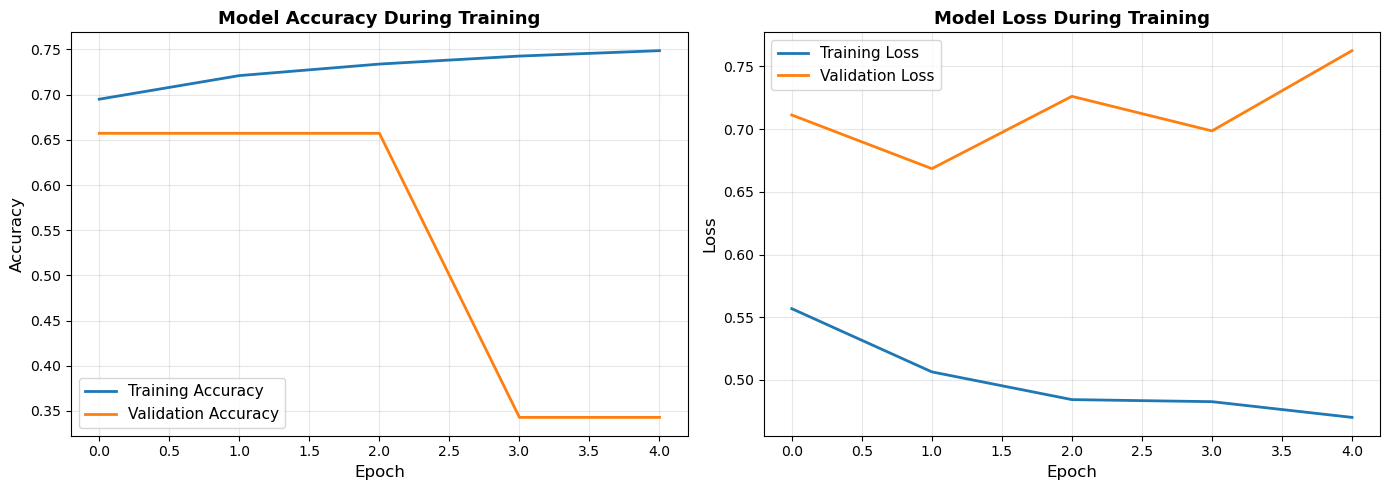


Training Summary:
Final Training Accuracy: 0.7487
Final Validation Accuracy: 0.3428
Final Training Loss: 0.4702
Final Validation Loss: 0.7626
Total Epochs Trained: 5


In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(cnn_history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[0].plot(cnn_history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Model Accuracy During Training', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Loss plot
axes[1].plot(cnn_history.history['loss'], label='Training Loss', linewidth=2)
axes[1].plot(cnn_history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('Model Loss During Training', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print training summary
print("\nTraining Summary:")
print(f"Final Training Accuracy: {cnn_history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {cnn_history.history['val_accuracy'][-1]:.4f}")
print(f"Final Training Loss: {cnn_history.history['loss'][-1]:.4f}")
print(f"Final Validation Loss: {cnn_history.history['val_loss'][-1]:.4f}")
print(f"Total Epochs Trained: {len(cnn_history.history['loss'])}")

In [313]:
y_prob = cnn_model.predict(val_dataset, verbose=0)
y_pred = np.argmax(y_prob, axis=1)
y_true = val_dataset.classes

In [319]:
from sklearn.metrics import precision_recall_fscore_support

cnn_prec, cnn_recall, cnn_f1, supp = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)

print(f'CNN precision: {cnn_prec:.4f}')
print(f'CNN recall: {cnn_recall:.4f}')
print(f'CNN F1 score: {cnn_f1:.4f}')

CNN precision: 0.4319
CNN recall: 0.6572
CNN F1 score: 0.5213


In [287]:
# TODO: define U-Net architecture

# U-Net hint: Build encoder (downsampling) then decoder (upsampling) with skip connections
# Encoder:  Conv -> ReLU -> MaxPool (4 levels)
# Decoder:  UpSampling -> Conv + concatenate from encoder
# Output:   Conv(1, 1x1, sigmoid) for binary segmentation

# TODO: train U-Net, compute IoU and Dice, visualize feature maps
# U-Net metrics hint:
# y_pred = unet_model.predict(X_test)
# iou = jaccard_score(y_test.flatten(), (y_pred > 0.5).flatten())
# dice = f1_score(y_test.flatten(), (y_pred > 0.5).flatten())

from tensorflow.keras import Input, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

def build_unet(input_size=(128, 128, 1), num_filters_start=32):
    """
    Build U-Net architecture for image segmentation.
    
    Args:
        input_size: Input image dimensions (height, width, channels)
        num_filters_start: Number of filters in first conv layer
        
    Returns:
        Compiled Keras model
    """
    inputs = Input(input_size)
    
    # Encoder (Contracting Path)
    print("Building U-Net Encoder...")
    
    # Block 1
    conv1 = layers.Conv2D(num_filters_start, (3,3), padding='same')(inputs)
    conv1 = layers.BatchNormalization()(conv1)
    conv1 = layers.Activation('relu')(conv1)
    conv1 = layers.Conv2D(num_filters_start, (3,3), padding='same')(conv1)
    conv1 = layers.BatchNormalization()(conv1)
    conv1 = layers.Activation('relu')(conv1)
    pool1 = layers.MaxPooling2D((2,2))(conv1)
    
    # Block 2
    conv2 = layers.Conv2D(num_filters_start*2, (3,3), padding='same')(pool1)
    conv2 = layers.BatchNormalization()(conv2)
    conv2 = layers.Activation('relu')(conv2)
    conv2 = layers.Conv2D(num_filters_start*2, (3,3), padding='same')(conv2)
    conv2 = layers.BatchNormalization()(conv2)
    conv2 = layers.Activation('relu')(conv2)
    pool2 = layers.MaxPooling2D((2,2))(conv2)
    
    # Block 3
    conv3 = layers.Conv2D(num_filters_start*4, (3,3), padding='same')(pool2)
    conv3 = layers.BatchNormalization()(conv3)
    conv3 = layers.Activation('relu')(conv3)
    conv3 = layers.Conv2D(num_filters_start*4, (3,3), padding='same')(conv3)
    conv3 = layers.BatchNormalization()(conv3)
    conv3 = layers.Activation('relu')(conv3)
    pool3 = layers.MaxPooling2D((2,2))(conv3)

    # Block 4
    conv4 = layers.Conv2D(num_filters_start*8, (3,3), padding='same')(pool3)
    conv4 = layers.BatchNormalization()(conv4)
    conv4 = layers.Activation('relu')(conv4)
    conv4 = layers.Conv2D(num_filters_start*8, (3,3), padding='same')(conv4)
    conv4 = layers.BatchNormalization()(conv4)
    conv4 = layers.Activation('relu')(conv4)
    pool4 = layers.MaxPooling2D((2,2))(conv4)
    
    # Bottleneck
    print("Building U-Net Bottleneck...")
    bottle = layers.Conv2D(num_filters_start*16, (3,3), padding='same')(pool4)
    bottle = layers.BatchNormalization()(bottle)
    bottle = layers.Activation('relu')(bottle)
    bottle = layers.Conv2D(num_filters_start*16, (3,3), padding='same')(bottle)
    bottle = layers.BatchNormalization()(bottle)
    bottle = layers.Activation('relu')(bottle)
    
    # Decoder (Expanding Path)
    print("Building U-Net Decoder...")
    
    # Block 5 (Upsample)
    up5 = layers.UpSampling2D((2,2))(bottle)
    up5 = layers.Concatenate()([up5, conv4])
    conv5 = layers.Conv2D(num_filters_start*8, (3,3), padding='same')(up5)
    conv5 = layers.BatchNormalization()(conv5)
    conv5 = layers.Activation('relu')(conv5)
    conv5 = layers.Conv2D(num_filters_start*8, (3,3), padding='same')(conv5)
    conv5 = layers.BatchNormalization()(conv5)
    conv5 = layers.Activation('relu')(conv5)
    
    # Block 6 (Upsample)
    up6 = layers.UpSampling2D((2,2))(conv5)
    up6 = layers.Concatenate()([up6, conv3])
    conv6 = layers.Conv2D(num_filters_start*4, (3,3), padding='same')(up6)
    conv6 = layers.BatchNormalization()(conv6)
    conv6 = layers.Activation('relu')(conv6)
    conv6 = layers.Conv2D(num_filters_start*4, (3,3), padding='same')(conv6)
    conv6 = layers.BatchNormalization()(conv6)
    conv6 = layers.Activation('relu')(conv6)
    
    # Block 7 (Upsample)
    up7 = layers.UpSampling2D((2,2))(conv6)
    up7 = layers.Concatenate()([up7, conv2])
    conv7 = layers.Conv2D(num_filters_start*2, (3,3), padding='same')(up7)
    conv7 = layers.BatchNormalization()(conv7)
    conv7 = layers.Activation('relu')(conv7)
    conv7 = layers.Conv2D(num_filters_start*2, (3,3), padding='same')(conv7)
    conv7 = layers.BatchNormalization()(conv7)
    conv7 = layers.Activation('relu')(conv7)

    # Block 8 (Upsample)
    up8 = layers.UpSampling2D((2,2))(conv7)
    up8 = layers.Concatenate()([up8, conv1])
    conv8 = layers.Conv2D(num_filters_start, (3,3), padding='same')(up8)
    conv8 = layers.BatchNormalization()(conv8)
    conv8 = layers.Activation('relu')(conv8)
    conv8 = layers.Conv2D(num_filters_start, (3,3), padding='same')(conv8)
    conv8 = layers.BatchNormalization()(conv8)
    conv8 = layers.Activation('relu')(conv8)
    
    # Output layer - sigmoid for binary segmentation
    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(conv8)
    
    # Create model
    model = models.Model(inputs=inputs, outputs=outputs, name='UNet')
    
    return model

# Build U-Net model
print("Creating U-Net model...")
unet_model = build_unet()

# Count parameters
total_params = unet_model.count_params()
print(f"\nTotal U-Net Parameters: {total_params:,}")

Creating U-Net model...
Building U-Net Encoder...
Building U-Net Bottleneck...
Building U-Net Decoder...

Total U-Net Parameters: 7,857,857


In [294]:
from skimage.transform import resize

def _to_gray(img):
    """Return 2D grayscale from image (channels-last if needed)."""
    if img.ndim == 3:
        # For TEM data, we can use a single channel (or np.mean across channels).
        if img.shape[2] >= 1:
            return img[:, :, 0]
        else:
            return img.mean(axis=2)
    return img


def _enhance_image(gray, median_disk=3, clahe_clip=0.015):
    """Median filter + CLAHE; output float32 in [0,1]."""
    med = filters.median(gray, footprint=morphology.disk(median_disk))
    enh = exposure.equalize_adapthist(med, clip_limit=clahe_clip)  # float in [0,1]
    return enh.astype(np.float32)


def _resize_image(img, target_hw):
    """Resize image (float) with bilinear filtering + anti-aliasing."""
    return resize(
        img, target_hw, order=1, mode='reflect',
        anti_aliasing=True, preserve_range=True
    ).astype(np.float32)


def _resize_mask(mask, target_hw):
    """Resize mask (binary) with nearest-neighbor; keep {0,1}."""
    m = resize(
        mask.astype(np.uint8), target_hw, order=0,  # nearest neighbor
        mode='edge', anti_aliasing=False, preserve_range=True
    )
    return (m >= 0.5).astype(np.uint8)


def _proxy_mask_from_watershed(enhanced, min_area=5):
    """Generate a binary mask via Otsu + distance + watershed (proxy GT)."""
    thr = filters.threshold_otsu(enhanced)
    binary = enhanced > thr
    dist = ndi.distance_transform_edt(binary)
    peaks = morphology.local_maxima(dist)
    markers, _ = ndi.label(peaks)
    labels = segmentation.watershed(-dist, markers=markers, mask=binary)
    mask = (labels > 0).astype(np.uint8)

    # Optional: remove small objects (helps clean up noise)
    if min_area and min_area > 0:
        mask = morphology.remove_small_objects(mask.astype(bool), max_size=min_area).astype(np.uint8)
    return mask


def build_unet_XY(
    image_dir,
    mask_dir=None,
    target_size=(128, 128),
    limit=None,
    generate_proxy_masks=False,
    median_disk=3,
    clahe_clip=0.015,
):
    """
    Build U-Net-ready arrays:
      X: (N, H, W, 1) float32 in [0,1]
      Y: (N, H, W, 1) uint8  in {0,1}

    Parameters
    ----------
    image_dir : str or Path
        Directory containing raw images (no subfolders required).
    mask_dir : str or Path or None
        Directory containing mask images; filenames must match image basenames in image_dir.
        If None and generate_proxy_masks=True, proxy masks will be generated.
    target_size : (int, int)
        (height, width) for U-Net input (e.g., (128,128) or (256,256)).
    limit : int or None
        If set, only process first 'limit' images.
    generate_proxy_masks : bool
        If True and mask_dir is None, create masks from watershed (proxy labels).
    median_disk : int
        Disk radius for median filter.
    clahe_clip : float
        CLAHE clip limit.

    Returns
    -------
    X : np.ndarray
        (N, H, W, 1) float32 in [0,1]
    Y : np.ndarray
        (N, H, W, 1) uint8 in {0,1}
    """
    image_dir = Path(image_dir)
    mask_dir = Path(mask_dir) if mask_dir else None

    exts = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")
    img_paths = sorted([p for p in image_dir.iterdir() if p.suffix.lower() in exts])
    if limit:
        img_paths = img_paths[:limit]

    if len(img_paths) == 0:
        raise RuntimeError(f"No images found in {image_dir}")

    X_list, Y_list = [], []

    for p in img_paths:
        # ---- load & preprocess image ----
        img = imread(str(p))
        gray = _to_gray(img)
        enhanced = _enhance_image(gray, median_disk=median_disk, clahe_clip=clahe_clip)
        enh_resized = _resize_image(enhanced, target_size)
        X_list.append(enh_resized[..., None])  # (H, W, 1)

        # ---- load or generate mask ----
        if mask_dir is not None:
            mpath = mask_dir / p.name  # expects same filename
            if not mpath.exists():
                raise FileNotFoundError(f"Mask not found for {p.name} in {mask_dir}")
            m_raw = imread(str(mpath))
            if m_raw.ndim == 3:
                m_raw = _to_gray(m_raw)
            # If stored as 0/255 -> binarize to {0,1}
            m_bin = (m_raw >= 127.5).astype(np.uint8)
            m_resized = _resize_mask(m_bin, target_size)
            Y_list.append(m_resized[..., None])

        elif generate_proxy_masks:
            m_proxy = _proxy_mask_from_watershed(enhanced)
            m_resized = _resize_mask(m_proxy, target_size)
            Y_list.append(m_resized[..., None])
        else:
            raise ValueError("No masks: provide mask_dir or set generate_proxy_masks=True")

    X = np.stack(X_list).astype(np.float32)      # (N, H, W, 1), [0,1]
    Y = np.stack(Y_list).astype(np.float32)        # (N, H, W, 1), {0,1}
    return X, Y

# Build U-Net input X from the 'samples' folder, using first 100 images
IMAGE_DIR = '/Users/wkddk/matsci465/weeks3&4/raw_data'

X, Y = build_unet_XY(
    image_dir=IMAGE_DIR,
    mask_dir=None,
    target_size=(128, 128),
    limit=100,
    generate_proxy_masks=True,  # <-- proxy labels
    median_disk=3,
    clahe_clip=0.015
)

X_train = X
X_test = X[80:, :, :, :]
Y_train = Y
Y_test = Y[80:, :, :, :]

In [295]:
def dice_loss(y_true, y_pred, smooth=1.0):
    """
    Dice Loss = 1 - Dice Coefficient
    Dice Coefficient = 2 * |X ∩ Y| / (|X| + |Y|)
    """
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    dice_coef = (2.0 * intersection + smooth) / (
        tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth
    )
    return 1.0 - dice_coef

def dice_coefficient(y_true, y_pred, smooth=1.0):
    """Dice Coefficient metric (for monitoring during training)"""
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    return (2.0 * intersection + smooth) / (
        tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth
    )

def iou_metric(y_true, y_pred, smooth=1.0):
    """Intersection over Union (Jaccard Index)"""
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    union = tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

# Compile U-Net model
print("Compiling U-Net model...")
unet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=dice_loss,  # Use Dice Loss for segmentation
    metrics=['binary_accuracy', dice_coefficient, iou_metric]
)

Compiling U-Net model...


In [296]:
# Define callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

# Train the model
print("Training U-Net model...")
print(f"Training samples: {len(X_train)}")
print(f"Validation split: 20%")

start_time = time.perf_counter()
history = unet_model.fit(
    X_train, Y_train,
    batch_size=8,
    epochs=30,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)
end_time = time.perf_counter()

print("\nTraining complete!")
print(f'Runtime for U-Net model: {end_time - start_time:.4f} s')

Training U-Net model...
Training samples: 100
Validation split: 20%
Epoch 1/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 322ms/step - binary_accuracy: 0.4738 - dice_coefficient: 0.6272 - iou_metric: 0.4913 - loss: 0.3728 - val_binary_accuracy: 0.1274 - val_dice_coefficient: 0.0229 - val_iou_metric: 0.0116 - val_loss: 0.9773 - learning_rate: 0.0010
Epoch 2/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 245ms/step - binary_accuracy: 0.9685 - dice_coefficient: 0.8987 - iou_metric: 0.8161 - loss: 0.1013 - val_binary_accuracy: 0.1875 - val_dice_coefficient: 0.1542 - val_iou_metric: 0.0836 - val_loss: 0.8445 - learning_rate: 0.0010
Epoch 3/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 241ms/step - binary_accuracy: 0.9790 - dice_coefficient: 0.9210 - iou_metric: 0.8536 - loss: 0.0790 - val_binary_accuracy: 0.1232 - val_dice_coefficient: 1.8505e-05 - val_iou_metric: 1.5086e-05 - val_loss: 1.0000 - learning_rate: 0.0010
Epoch 4/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - binary_accuracy: 0.9860 - dice_coefficient: 0.9309 - iou_me

In [297]:
# Make predictions on test set
y_pred = unet_model.predict(X_test, verbose=0)

# Apply threshold to get binary masks (threshold = 0.5)
y_pred_binary = (y_pred > 0.5).astype(np.float32)

# Calculate metrics for each test sample
dice_scores = []
iou_scores = []

for i in range(len(X_test)):
    # Flatten for metric calculation
    y_true_flat = Y_test[i].flatten()
    y_pred_flat = y_pred_binary[i].flatten()
    
    # Dice coefficient
    dice = (2 * np.sum(y_true_flat * y_pred_flat)) / (np.sum(y_true_flat) + np.sum(y_pred_flat) + 1e-7)
    dice_scores.append(dice)
    
    # IoU
    intersection = np.sum(y_true_flat * y_pred_flat)
    union = np.sum(y_true_flat) + np.sum(y_pred_flat) - intersection
    iou = intersection / (union + 1e-7)
    iou_scores.append(iou)

print(f"\nPer-Sample Metrics:")
print(f"Mean Dice Coefficient: {np.mean(dice_scores):.4f} ± {np.std(dice_scores):.4f}")
print(f"Mean IoU: {np.mean(iou_scores):.4f} ± {np.std(iou_scores):.4f}")
print(f"Min IoU: {np.min(iou_scores):.4f}")
print(f"Max IoU: {np.max(iou_scores):.4f}")


Per-Sample Metrics:
Mean Dice Coefficient: 0.9451 ± 0.0172
Mean IoU: 0.8965 ± 0.0309
Min IoU: 0.8458
Max IoU: 0.9461


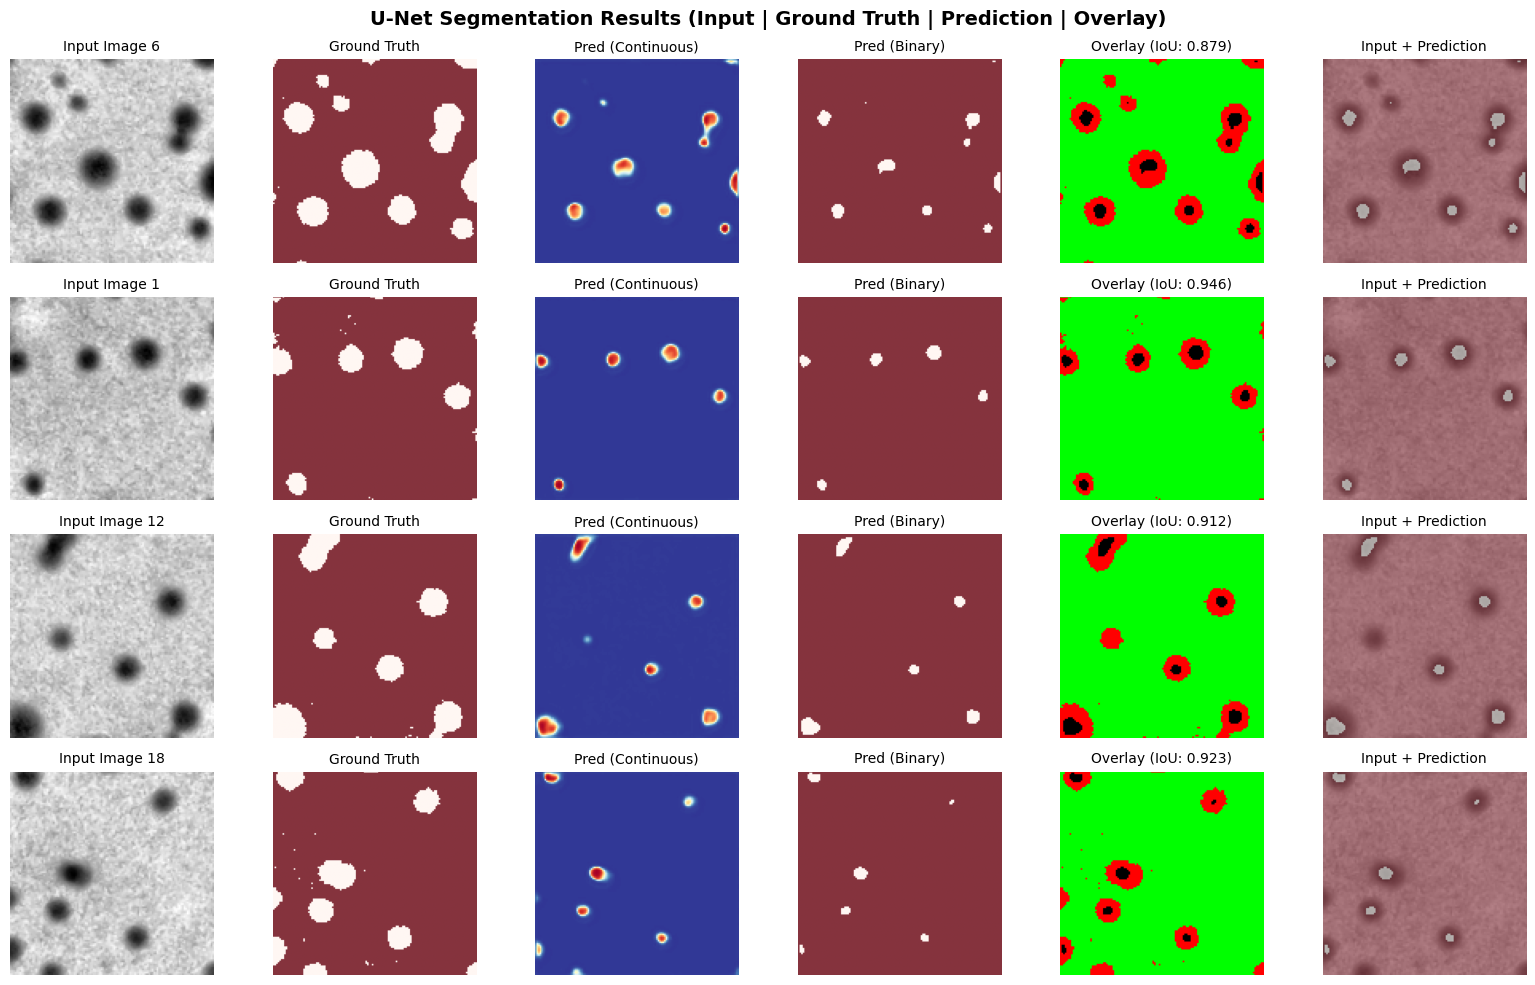

Segmentation visualization complete!


In [302]:
# Visualize segmentation results
fig, axes = plt.subplots(4, 6, figsize=(16, 10))
fig.suptitle('U-Net Segmentation Results (Input | Ground Truth | Prediction | Overlay)', 
             fontsize=14, fontweight='bold')

sample_indices = np.random.choice(len(X_test), size=4, replace=False)

for row, sample_idx in enumerate(sample_indices):
    # Input image
    ax = axes[row, 0]
    ax.imshow(X_test[sample_idx].squeeze(), cmap='gray')
    ax.set_title(f'Input Image {sample_idx}', fontsize=10)
    ax.axis('off')
    
    # Ground truth mask
    ax = axes[row, 1]
    ax.imshow(Y_test[sample_idx].squeeze(), cmap='Reds', alpha=0.8)
    ax.set_title('Ground Truth', fontsize=10)
    ax.axis('off')
    
    # Predicted mask (continuous)
    ax = axes[row, 2]
    ax.imshow(y_pred[sample_idx].squeeze(), cmap='RdYlBu')
    ax.set_title('Pred (Continuous)', fontsize=10)
    ax.axis('off')
    
    # Predicted mask (binary)
    ax = axes[row, 3]
    ax.imshow(y_pred_binary[sample_idx].squeeze(), cmap='Reds', alpha=0.8)
    ax.set_title('Pred (Binary)', fontsize=10)
    ax.axis('off')
    
    # Overlay: True positive (green), False positive (red), False negative (blue)
    ax = axes[row, 4]
    tp = Y_test[sample_idx].squeeze() * y_pred_binary[sample_idx].squeeze()
    fp = (1 - Y_test[sample_idx].squeeze()) * y_pred_binary[sample_idx].squeeze()
    fn = Y_test[sample_idx].squeeze() * (1 - y_pred_binary[sample_idx].squeeze())
    
    overlay = np.zeros((*Y_test[sample_idx].shape[:-1], 3))
    overlay[..., 0] = fp  # False positives in red
    overlay[..., 1] = tp  # True positives in green
    overlay[..., 2] = fn  # False negatives in blue
    
    ax.imshow(overlay)
    ax.set_title(f'Overlay (IoU: {iou_scores[sample_idx]:.3f})', fontsize=10)
    ax.axis('off')
    
    # Input with prediction overlay
    ax = axes[row, 5]
    ax.imshow(X_test[sample_idx].squeeze(), cmap='gray', alpha=0.7)
    ax.imshow(y_pred_binary[sample_idx].squeeze(), cmap='Reds', alpha=0.5)
    ax.set_title('Input + Prediction', fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

fig.savefig('unetsegmentation.png', dpi=300, bbox_inches='tight')

print("Segmentation visualization complete!")

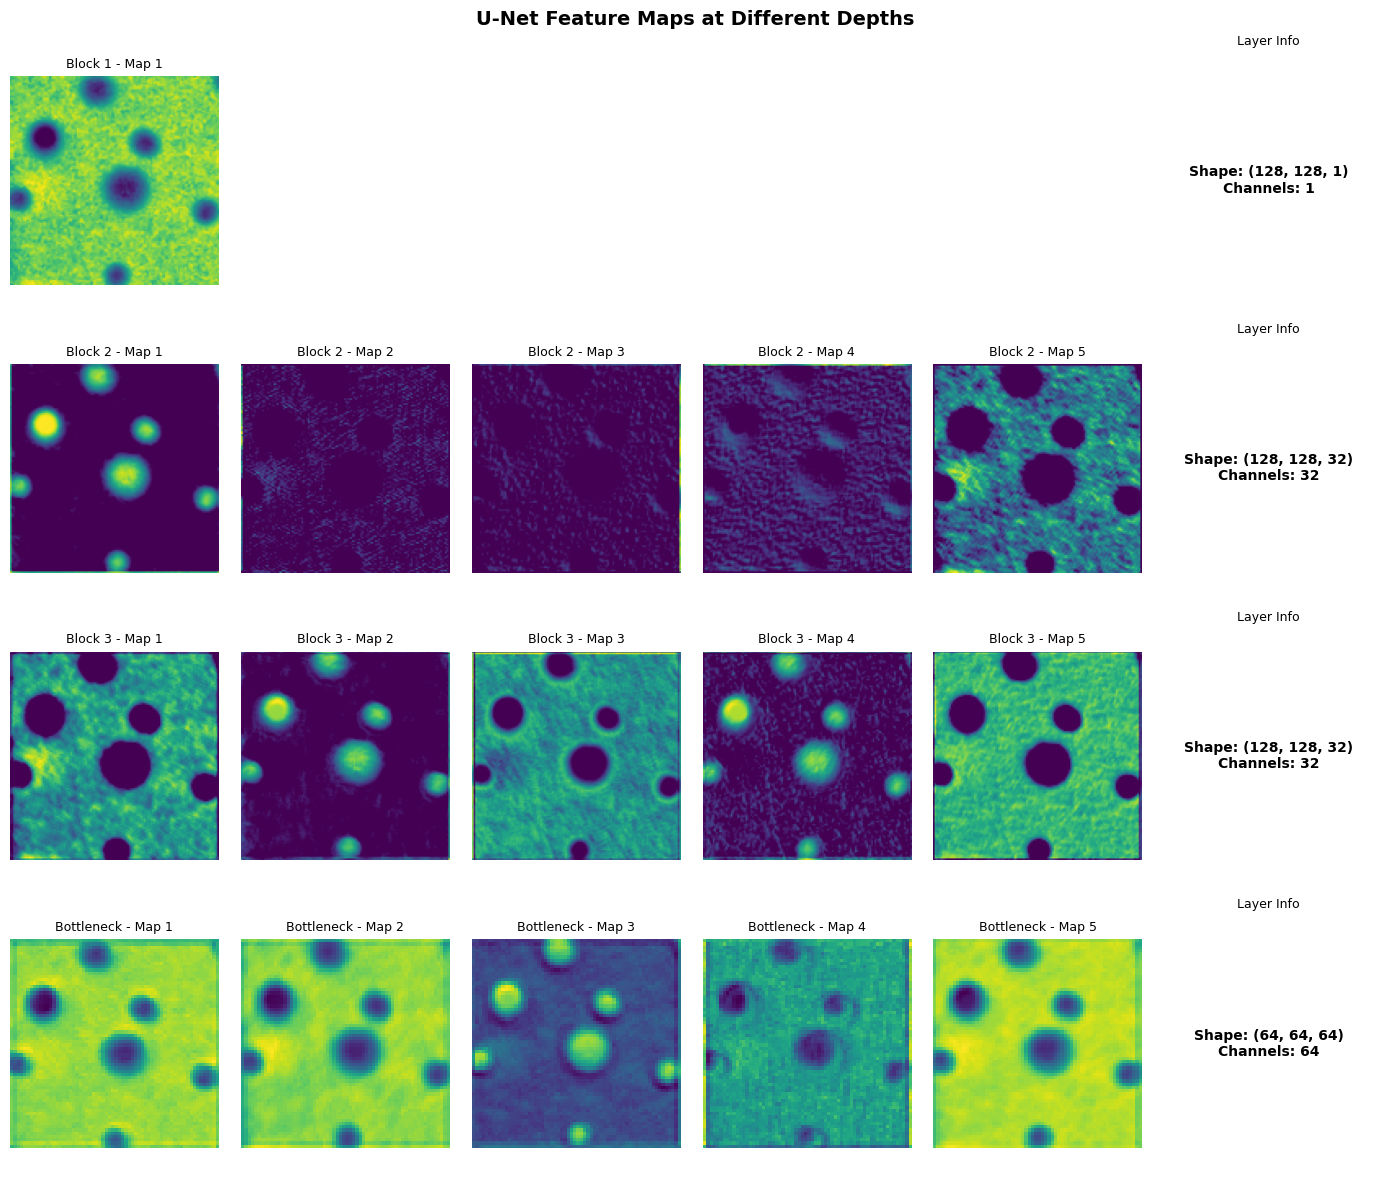

Feature map visualization complete!


In [303]:
# 5. Visualization:
#    - Plot training curves: plt.plot(history.history['loss'], label='train')
#    - Show ground truth vs predictions side by side
#    - Display intermediate feature maps from encoder layers

# Extract intermediate feature maps from different layers
sample_image = X_test[0:1]

# Get layer indices for visualization (encoder layers)
# Layers 0, 3, 6 correspond to first convolution outputs in each encoder block
layer_indices = [0, 3, 6, 9]  # Different depths in encoder
layer_names = ['Block 1', 'Block 2', 'Block 3', 'Bottleneck']

fig, axes = plt.subplots(4, 6, figsize=(14, 12))
fig.suptitle('U-Net Feature Maps at Different Depths', fontsize=14, fontweight='bold')

for row, (layer_idx, layer_name) in enumerate(zip(layer_indices, layer_names)):
    # Create intermediate model
    intermediate_model = keras.Model(
        inputs=unet_model.input,
        outputs=unet_model.layers[layer_idx].output
    )
    
    # Get feature maps
    feature_maps = intermediate_model.predict(sample_image, verbose=0)
    
    # Plot first 5 feature maps
    for col in range(6):
        ax = axes[row, col]
        
        if col < min(5, feature_maps.shape[-1]):
            # Normalize feature map for visualization
            fmap = feature_maps[0, :, :, col]
            fmap_normalized = (fmap - fmap.min()) / (fmap.max() - fmap.min() + 1e-7)
            
            ax.imshow(fmap_normalized, cmap='viridis')
            ax.set_title(f'{layer_name} - Map {col+1}', fontsize=9)
        elif col == 5:
            # Last subplot shows shape info
            ax.text(0.5, 0.5, f'Shape: {feature_maps.shape[1:]}\n' + 
                            f'Channels: {feature_maps.shape[-1]}',
                   ha='center', va='center', fontsize=10, fontweight='bold')
            ax.set_title('Layer Info', fontsize=9)
        
        ax.axis('off')

plt.tight_layout()
plt.show()

fig.savefig('unetfeaturemaps.png', dpi=300, bbox_inches='tight')

print("Feature map visualization complete!")

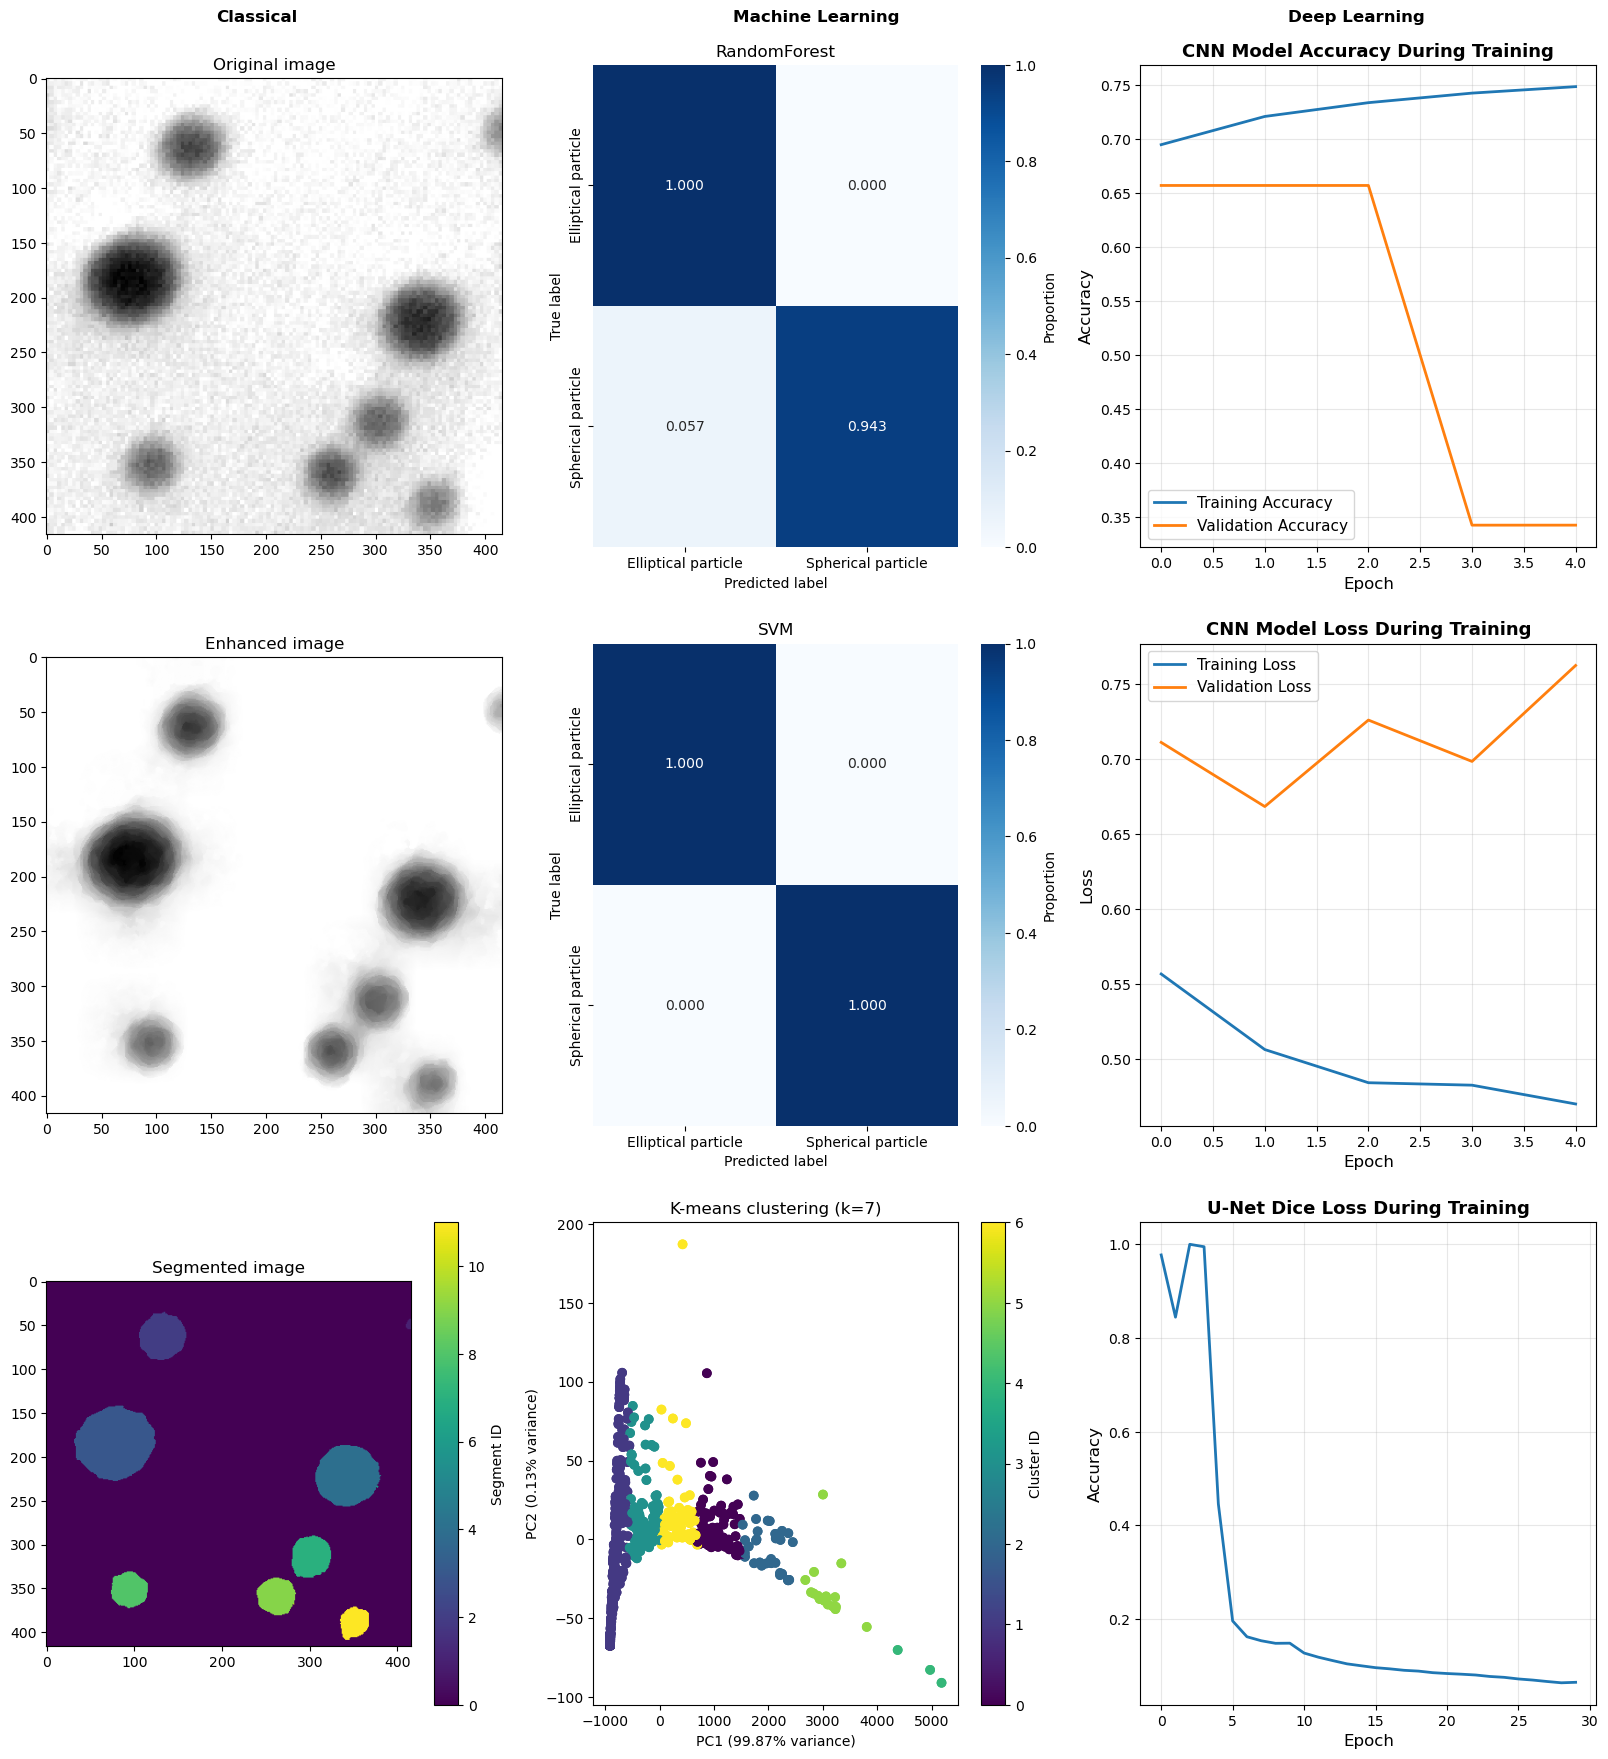

In [300]:
# Final visualization of all models
fig, axs = plt.subplots(3, 3, figsize=(20,20))

# Column titles on the top row
col_titles = ["Classical", "Machine Learning", "Deep Learning"]

fig.subplots_adjust(top=0.93)

# Column headers positioned in figure coordinates
column_positions = [0.23, 0.51, 0.78]
for c, title in enumerate(col_titles):
    fig.text(column_positions[c], 0.95, title,
             ha='center', va='bottom', fontsize=12, fontweight='bold')

axs[0,0].imshow(raw_image,cmap='gray')
axs[0,0].set_title('Original image')

enhanced_visualization = exposure.equalize_adapthist(ndi.median_filter(raw_image, footprint=morphology.disk(5)), clip_limit=0.005)
axs[1,0].imshow(enhanced_visualization, cmap='gray')
axs[1,0].set_title('Enhanced image')

threshold = filters.threshold_otsu(enhanced_visualization)
binary = enhanced_visualization < threshold
binary = morphology.remove_small_objects(binary, max_size=20)
binary = morphology.remove_small_holes(binary, max_size=20)
distance = ndi.distance_transform_edt(binary)
coords = peak_local_max(distance, footprint=np.ones((3, 3)), labels=binary)
mask = np.zeros(distance.shape, dtype=bool)
mask[tuple(coords.T)] = True
markers, _ = ndi.label(mask)
labels_visualization = watershed(-distance, markers, mask=binary)
labeled = axs[2,0].imshow(labels_visualization)
axs[2,0].set_title('Segmented image')
plt.colorbar(labeled, ax=axs[2,0], label='Segment ID')

for i, (name, result) in enumerate(results.items()):
    cm = result['confusion_matrix']
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    seaborn.heatmap(cm_norm, annot=True, fmt='.3f', cmap='Blues',
                   xticklabels=['Elliptical particle', 'Spherical particle'],
                   yticklabels=['Elliptical particle', 'Spherical particle'],
                   ax=axs[i,1], cbar_kws={'label': 'Proportion'})
    axs[i,1].set_title(name)
    axs[i,1].set_xlabel('Predicted label')
    axs[i,1].set_ylabel('True label')

scatter3 = axs[2,1].scatter(features_pca[:,0], features_pca[:,1], c=labels[2])
axs[2,1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
axs[2,1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
axs[2,1].set_title('K-means clustering (k=7)')
plt.colorbar(scatter3, ax=axs[2,1], label='Cluster ID')

axs[0,2].plot(cnn_history.history['accuracy'], label='Training Accuracy', linewidth=2)
axs[0,2].plot(cnn_history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axs[0,2].set_xlabel('Epoch', fontsize=12)
axs[0,2].set_ylabel('Accuracy', fontsize=12)
axs[0,2].set_title('CNN Model Accuracy During Training', fontsize=13, fontweight='bold')
axs[0,2].legend(fontsize=11)
axs[0,2].grid(True, alpha=0.3)

axs[1,2].plot(cnn_history.history['loss'], label='Training Loss', linewidth=2)
axs[1,2].plot(cnn_history.history['val_loss'], label='Validation Loss', linewidth=2)
axs[1,2].set_xlabel('Epoch', fontsize=12)
axs[1,2].set_ylabel('Loss', fontsize=12)
axs[1,2].set_title('CNN Model Loss During Training', fontsize=13, fontweight='bold')
axs[1,2].legend(fontsize=11)
axs[1,2].grid(True, alpha=0.3)

axs[2,2].plot(history.history['val_loss'], linewidth=2)
axs[2,2].set_xlabel('Epoch', fontsize=12)
axs[2,2].set_ylabel('Accuracy', fontsize=12)
axs[2,2].set_title('U-Net Dice Loss During Training', fontsize=13, fontweight='bold')
axs[2,2].grid(True, alpha=0.3)

fig.savefig('3x3VisualizationCollage.png', dpi=300, bbox_inches='tight')

In [326]:
methods = ['classical', 'RandomForest', 'SVM', 'k-means (k=7)', 'CNN', 'U-Net']
runtimes = [0.1510, 0.092939, 0.004934, 0.0103, 225.4264, 92.2103]
metrics = ['mean dice = 1.0000, mean iou = 1.0000', 'f1 = 0.970874', 'f1 = 1.0000', 'silhouette = 0.629 (k=7)', 'f1 = 0.5213', 'mean dice = 0.9451, mean iou = 0.8965']
labels_needed = [False, True, True, False, True, False]
interpretability = ['High (segmentation performed manually)', 'High (feature importance performed beforehand)', 'High (feature importance performed beforehand)', 'Average (unsupervised learning)', 'Low (effectively a black box)', 'Average (makes some use of manual segmentation operations)']
comparison = {
    'methods': methods,
    'runtimes (s)': runtimes,
    'metrics (accuracy/silhouette/f1/iou)': metrics,
    'labels needed?': labels_needed,
    'interpretability': interpretability
}
comparison_table = pd.DataFrame(comparison)
display(comparison_table)
comparison_table.to_csv('comparison_table.csv')

,methods,runtimes (s),metrics (accuracy/silhouette/f1/iou),labels needed?,interpretability
0,classical,0.151000,"mean dice = 1.0000, mean iou = 1.0000",False,High (segmentation performed manually)
1,RandomForest,0.092939,f1 = 0.970874,True,High (feature importance performed beforehand)
2,SVM,0.004934,f1 = 1.0000,True,High (feature importance performed beforehand)
3,k-means (k=7),0.010300,silhouette = 0.629 (k=7),False,Average (unsupervised learning)
4,CNN,225.426400,f1 = 0.5213,True,Low (effectively a black box)
5,U-Net,92.210300,"mean dice = 0.9451, mean iou = 0.8965",False,Average (makes some use of manual segmentation...


## Dataset: DOPAD (Dataset Of nanoPArticle Detection)

**Overview:**
- **272 original TEM images** at varying resolutions (~1.5M total particles)
- High-resolution nanoparticle detection annotations
- Diverse imaging environments and particle morphologies

**Note:** You do **not** need to use all 272 images. Using **100images** is sufficient for this assignment and will provide excellent statistical validation while keeping computational cost manageable.

**Download:** https://dopad.github.io/docs/download/

**Citation:** Qu et al. - For academic use, cite appropriately per repository guidelines.

## Deliverables Checklist
- [ ] Classical pipeline outputs (`classical_results.csv`, four-panel figure).
- [ ] ML analyses (`ml_results.csv`, confusion matrices, clustering visualizations).
- [ ] Deep learning artifacts (training curves, segmentation outputs, feature maps).
- [ ] Comparison table summarizing methods and metrics.
- [ ] Final 3×3 visualization collage.
- [ ] README.md documenting methodology, quantitative comparisons, and recommendations.
- [ ] Publication-quality figures with scale bars and repository submission.